# **PREPROCESSING OF DATA**

In [45]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
ACN_PATH       = '../data/raw/acn/acndata_sessions.json.xlsx'
ST_EVCDP_PATH  = '../data/raw/st_evcdp/'
PROCESSED_PATH = '../data/processed/'

os.makedirs(PROCESSED_PATH, exist_ok=True)

In [48]:
ACN_PATH = '/content/acndata_sessions.json.xlsx'
df_acn = pd.read_excel(ACN_PATH)


drop_cols = ['_meta', 'end', 'start', 'min_kWh', '_items', 'userID.1', 'modifiedAt']
df_acn.drop(columns=[c for c in drop_cols if c in df_acn.columns], inplace=True)


for col in ['connectionTime', 'disconnectTime', 'doneChargingTime']:
    df_acn[col] = pd.to_datetime(df_acn[col], utc=True, errors='coerce')


before = len(df_acn)
df_acn.dropna(subset=['connectionTime', 'disconnectTime', 'kWhDelivered'], inplace=True)
print(f"Dropped {before - len(df_acn)} rows")


df_acn = df_acn[df_acn['kWhDelivered'] > 0]


df_acn['session_duration_hrs'] = (
    df_acn['disconnectTime'] - df_acn['connectionTime']
).dt.total_seconds() / 3600

df_acn = df_acn[df_acn['session_duration_hrs'] > 0]
df_acn = df_acn[df_acn['session_duration_hrs'] < 24]

df_acn['hour_of_day']  = df_acn['connectionTime'].dt.hour
df_acn['day_of_week']  = df_acn['connectionTime'].dt.dayofweek  # 0=Monday
df_acn['is_weekend']   = df_acn['day_of_week'].isin([5, 6]).astype(int)
df_acn['month']        = df_acn['connectionTime'].dt.month
df_acn['date']         = df_acn['connectionTime'].dt.date


BASELINE_TARIFF = 15
df_acn['revenue_session']    = df_acn['kWhDelivered'] * BASELINE_TARIFF
df_acn['charging_rate_kw']   = df_acn['kWhDelivered'] / df_acn['session_duration_hrs']

print(f"ACN cleaned shape: {df_acn.shape}")
df_acn[['connectionTime','kWhDelivered','session_duration_hrs','hour_of_day','revenue_session']].head(3)

Dropped 1305 rows
ACN cleaned shape: (14848, 28)


,connectionTime,kWhDelivered,session_duration_hrs,hour_of_day,revenue_session
0,2018-04-25 11:08:04+00:00,7.932,2.201667,11,118.980
1,2018-04-25 13:45:10+00:00,10.013,11.185000,13,150.195
2,2018-04-25 13:45:50+00:00,5.257,9.315278,13,78.855


In [49]:
ST_EVCDP_PATH  = '/content/'
occupancy = pd.read_csv(ST_EVCDP_PATH + 'occupancy.csv', index_col=0)
volume    = pd.read_csv(ST_EVCDP_PATH + 'volume.csv',    index_col=0)
duration  = pd.read_csv(ST_EVCDP_PATH + 'duration.csv',  index_col=0)
price     = pd.read_csv(ST_EVCDP_PATH + 'price.csv',     index_col=0)
time_df   = pd.read_csv(ST_EVCDP_PATH + 'time.csv')
stations  = pd.read_csv(ST_EVCDP_PATH + 'stations.csv')

print("occupancy :", occupancy.shape)
print("volume    :", volume.shape)
print("duration  :", duration.shape)
print("price     :", price.shape)
print("time      :", time_df.shape)
print("stations  :", stations.shape)

print("\nStation IDs (first 5):", occupancy.columns[:5].tolist())
print("\noccupancy sample:\n", occupancy.iloc[:3, :4])
print("\nprice sample:\n", price.iloc[:3, :4])

occupancy : (8640, 247)
volume    : (8640, 247)
duration  : (8640, 247)
price     : (8640, 247)
time      : (8640, 6)
stations  : (1706, 6)

Station IDs (first 5): ['102', '105', '107', '108', '109']

occupancy sample:
            102  105  107  108
timestamp                    
1           12   16   24   15
2           12   16   24   15
3           12   16   24   15

price sample:
              102       105       107   108
timestamp                                 
1          0.924  1.124167  0.926364  0.99
2          0.924  1.124167  0.926364  0.99
3          0.924  1.124167  0.926364  0.99


In [50]:
timestamps = pd.to_datetime({
    'year':   time_df['year'],
    'month':  time_df['month'],
    'day':    time_df['day'],
    'hour':   time_df['hour'],
    'minute': time_df['minute'],
    'second': time_df['second']
})


min_rows = min(len(timestamps), len(occupancy))
timestamps        = timestamps.iloc[:min_rows]
occupancy_trimmed = occupancy.iloc[:min_rows].astype(float)
volume_trimmed    = volume.iloc[:min_rows].astype(float)
duration_trimmed  = duration.iloc[:min_rows].astype(float)
price_trimmed     = price.iloc[:min_rows].astype(float)


station_ids = occupancy_trimmed.columns.tolist()
n_times     = len(timestamps)
n_stations  = len(station_ids)

print(f"{n_times * n_stations:,} rows")

ts_repeated = np.repeat(timestamps.values, n_stations)
st_tiled    = np.tile(station_ids, n_times)

df_ev = pd.DataFrame({
    'timestamp'    : ts_repeated,
    'station_id'   : st_tiled,
    'occupancy'    : occupancy_trimmed.values.flatten(),
    'volume'       : volume_trimmed.values.flatten(),
    'duration_mins': duration_trimmed.values.flatten(),
    'price_per_kwh': price_trimmed.values.flatten(),
})

df_ev['timestamp'] = pd.to_datetime(df_ev['timestamp'])
df_ev['station_id'] = df_ev['station_id'].astype(str)


df_ev['hour_of_day'] = df_ev['timestamp'].dt.hour
df_ev['day_of_week'] = df_ev['timestamp'].dt.dayofweek
df_ev['is_weekend']  = df_ev['day_of_week'].isin([5,6]).astype(int)
df_ev['month']       = df_ev['timestamp'].dt.month
df_ev['date']        = df_ev['timestamp'].dt.date


stations['station_id'] = stations['station_id'].astype(str)
df_ev = df_ev.sort_values(['station_id','timestamp']).reset_index(drop=True)
df_ev = df_ev.merge(stations[['station_id','count']], on='station_id', how='left')


df_ev['utilization_rate'] = (df_ev['occupancy'] / df_ev['count']).clip(0, 1)

df_ev['congestion_flag'] = (df_ev['utilization_rate'] > 0.8).astype(int)
df_ev['low_demand_flag'] = (df_ev['utilization_rate'] < 0.3).astype(int)

print(f"Shape: {df_ev.shape}")
print(f"Date range: {df_ev['timestamp'].min()} to {df_ev['timestamp'].max()}")
print(f"\nValue ranges:")
print(f"  occupancy : {df_ev['occupancy'].min():.2f} to {df_ev['occupancy'].max():.2f}")
print(f"  volume    : {df_ev['volume'].min():.2f} to {df_ev['volume'].max():.2f}")
print(f"  price     : {df_ev['price_per_kwh'].min():.2f} to {df_ev['price_per_kwh'].max():.2f}")
print(f"  duration  : {df_ev['duration_mins'].min():.2f} to {df_ev['duration_mins'].max():.2f}")
df_ev.head(3)

2,134,080 rows
Shape: (2134080, 15)
Date range: 2022-06-19 00:00:00 to 2022-07-18 23:55:00

Value ranges:
  occupancy : 0.00 to 220.00
  volume    : 0.00 to 1492.50
  price     : 0.25 to 1.47
  duration  : 0.00 to 17.08


,timestamp,station_id,occupancy,volume,duration_mins,price_per_kwh,hour_of_day,day_of_week,is_weekend,month,date,count,utilization_rate,congestion_flag,low_demand_flag
0,2022-06-19 00:00:00,1000,60.0,16.197222,3.157778,0.894267,0,6,1,6,2022-06-19,10,1.0,1,0
1,2022-06-19 00:05:00,1000,60.0,24.791667,4.833333,0.894267,0,6,1,6,2022-06-19,10,1.0,1,0
2,2022-06-19 00:10:00,1000,60.0,24.791667,4.833333,0.894267,0,6,1,6,2022-06-19,10,1.0,1,0


In [51]:
df_acn.to_csv(PROCESSED_PATH + 'acn_caltech_processed.csv', index=False)
df_ev.to_csv(PROCESSED_PATH + 'st_evcdp_processed.csv', index=False)

print(f"  acn_caltech_processed.csv  — {df_acn.shape}")
print(f"  st_evcdp_processed.csv     — {df_ev.shape}")


  acn_caltech_processed.csv  — (14848, 28)
  st_evcdp_processed.csv     — (2134080, 15)


## **DATA ANALYSIS**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='darkgrid')

PROCESSED_PATH = '../data/processed/'
OUTPUT_PATH    = '../outputs/'
import os; os.makedirs(OUTPUT_PATH, exist_ok=True)

df_acn = pd.read_csv(PROCESSED_PATH + 'acn_caltech_processed.csv', parse_dates=['connectionTime','disconnectTime'])
df_ev  = pd.read_csv(PROCESSED_PATH + 'st_evcdp_processed.csv',    parse_dates=['timestamp'])

print("ACN shape :", df_acn.shape)
print("EV shape  :", df_ev.shape)

ACN shape : (14848, 28)
EV shape  : (2134080, 15)


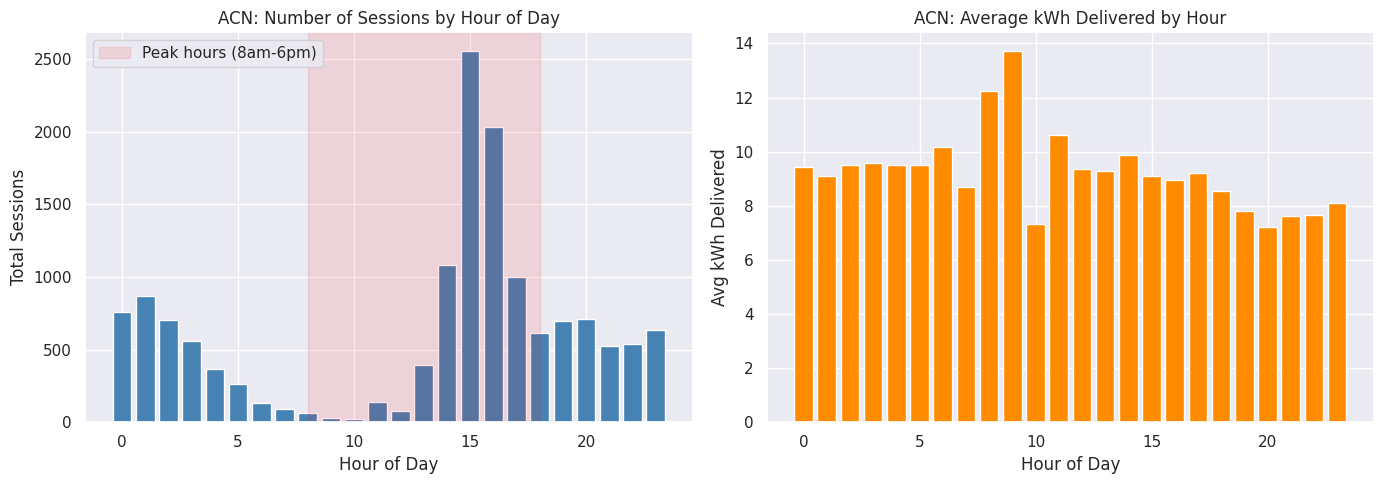

Peak charging hours and average energy consumption pattern


In [82]:
hourly_acn = df_acn.groupby('hour_of_day').agg(
    avg_sessions  = ('kWhDelivered', 'count'),
    avg_kwh       = ('kWhDelivered', 'mean'),
    avg_revenue   = ('revenue_session', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly_acn['hour_of_day'], hourly_acn['avg_sessions'], color='steelblue')
axes[0].set_title('ACN: Number of Sessions by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Total Sessions')
axes[0].axvspan(8, 18, alpha=0.1, color='red', label='Peak hours (8am-6pm)')
axes[0].legend()

axes[1].bar(hourly_acn['hour_of_day'], hourly_acn['avg_kwh'], color='darkorange')
axes[1].set_title('ACN: Average kWh Delivered by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg kWh Delivered')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'acn_hourly_demand.png', bbox_inches='tight')
plt.show()
print("Peak charging hours and average energy consumption pattern")

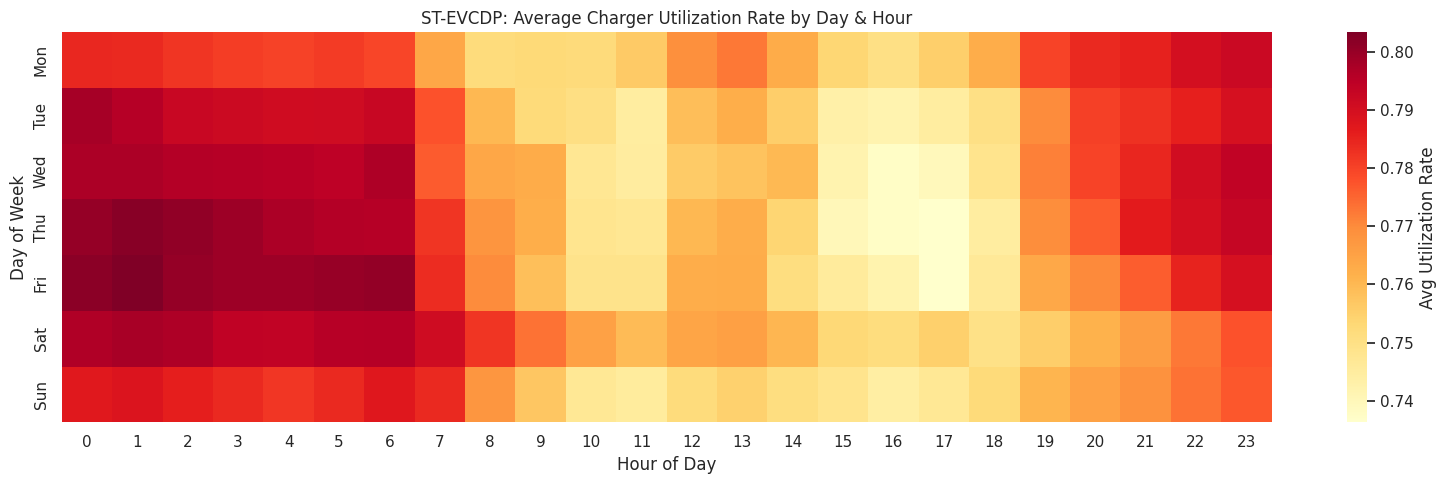

Which day/hour combos have peak utilization : directly drives surge pricing logic


In [83]:
heatmap_data = df_ev.groupby(['day_of_week','hour_of_day'])['utilization_rate'].mean().unstack()
heatmap_data.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False,
            cbar_kws={'label': 'Avg Utilization Rate'})
plt.title('ST-EVCDP: Average Charger Utilization Rate by Day & Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'evcdp_utilization_heatmap.png', bbox_inches='tight')
plt.show()
print("Which day/hour combos have peak utilization : directly drives surge pricing logic")

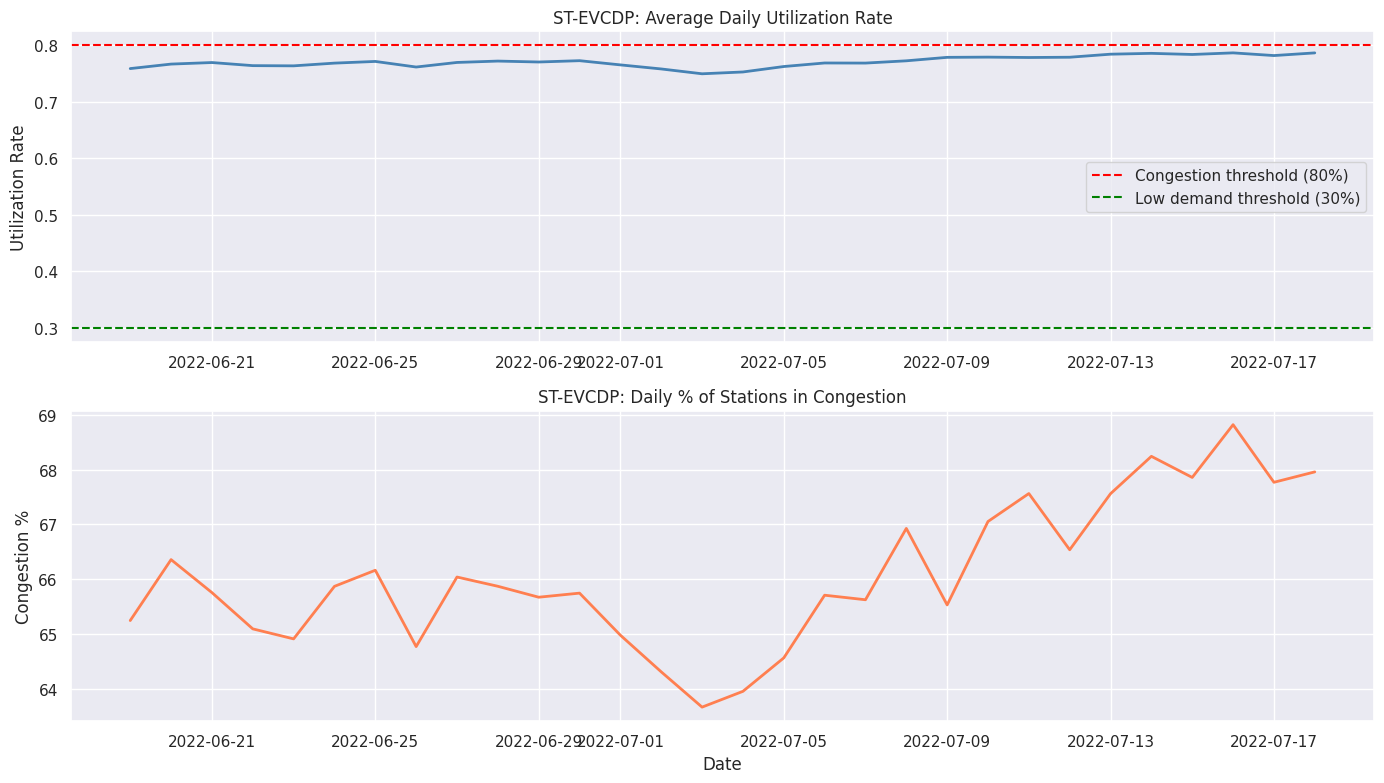

In [84]:
daily_ev = df_ev.groupby('date').agg(
    avg_utilization = ('utilization_rate', 'mean'),
    avg_volume      = ('volume', 'mean'),
    congestion_pct  = ('congestion_flag', 'mean')
).reset_index()
daily_ev['date'] = pd.to_datetime(daily_ev['date'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily_ev['date'], daily_ev['avg_utilization'], color='steelblue', linewidth=2)
axes[0].set_title('ST-EVCDP: Average Daily Utilization Rate')
axes[0].set_ylabel('Utilization Rate')
axes[0].axhline(0.8, color='red', linestyle='--', label='Congestion threshold (80%)')
axes[0].axhline(0.3, color='green', linestyle='--', label='Low demand threshold (30%)')
axes[0].legend()

axes[1].plot(daily_ev['date'], daily_ev['congestion_pct']*100, color='coral', linewidth=2)
axes[1].set_title('ST-EVCDP: Daily % of Stations in Congestion')
axes[1].set_ylabel('Congestion %')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'evcdp_demand_over_time.png', bbox_inches='tight')
plt.show()

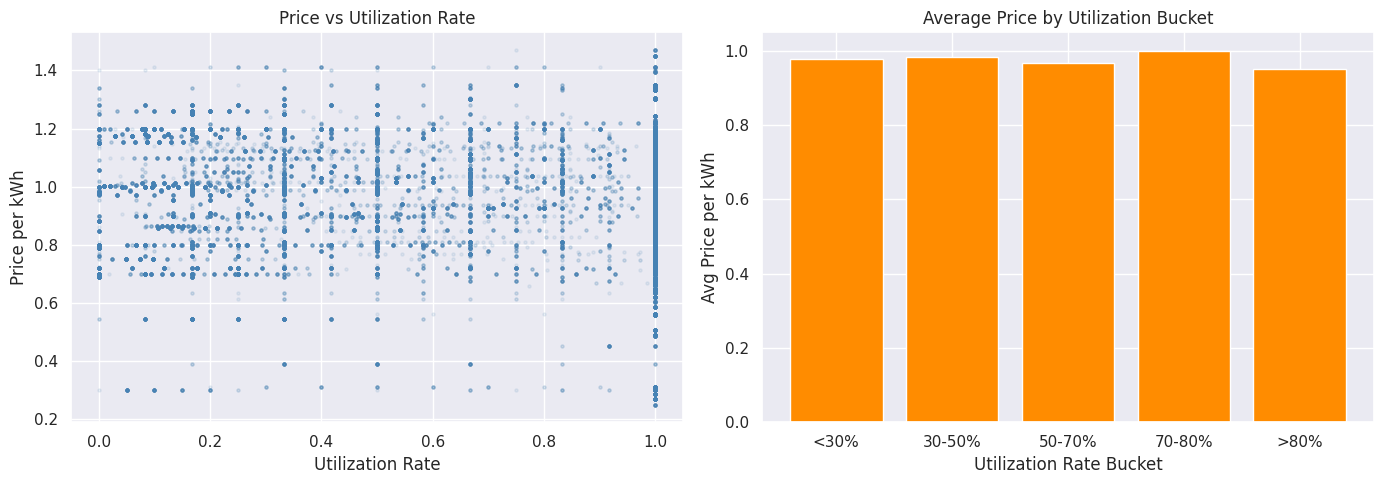

This shows whether current pricing already correlates with demand, key for tariff design


In [58]:
sample = df_ev.sample(50000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['utilization_rate'], sample['price_per_kwh'],
                alpha=0.1, color='steelblue', s=5)
axes[0].set_title('Price vs Utilization Rate')
axes[0].set_xlabel('Utilization Rate')
axes[0].set_ylabel('Price per kWh')


df_ev['util_bucket'] = pd.cut(df_ev['utilization_rate'],
                               bins=[0, 0.3, 0.5, 0.7, 0.8, 1.0],
                               labels=['<30%','30-50%','50-70%','70-80%','>80%'])
price_by_util = df_ev.groupby('util_bucket')['price_per_kwh'].mean()

axes[1].bar(price_by_util.index, price_by_util.values, color='darkorange')
axes[1].set_title('Average Price by Utilization Bucket')
axes[1].set_xlabel('Utilization Rate Bucket')
axes[1].set_ylabel('Avg Price per kWh')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'evcdp_price_vs_utilization.png', bbox_inches='tight')
plt.show()
print("This shows whether current pricing already correlates with demand, key for tariff design")

In [59]:
acn_summary = pd.DataFrame({
    'metric': ['Total Sessions', 'Avg kWh/Session', 'Avg Duration (hrs)',
               'Avg Revenue/Session (Rs)', 'Peak Hour', 'Median kWh'],
    'value': [
        len(df_acn),
        round(df_acn['kWhDelivered'].mean(), 2),
        round(df_acn['session_duration_hrs'].mean(), 2),
        round(df_acn['revenue_session'].mean(), 2),
        df_acn.groupby('hour_of_day')['kWhDelivered'].count().idxmax(),
        round(df_acn['kWhDelivered'].median(), 2)
    ]
})


ev_summary = pd.DataFrame({
    'metric': ['Total Records', 'Avg Utilization Rate', 'Congestion % of Time',
               'Low Demand % of Time', 'Avg Price/kWh', 'Unique Stations'],
    'value': [
        len(df_ev),
        round(df_ev['utilization_rate'].mean(), 3),
        round(df_ev['congestion_flag'].mean() * 100, 1),
        round(df_ev['low_demand_flag'].mean() * 100, 1),
        round(df_ev['price_per_kwh'].mean(), 3),
        df_ev['station_id'].nunique()
    ]
})

acn_summary.to_csv(OUTPUT_PATH + 'acn_eda_summary.csv', index=False)
ev_summary.to_csv(OUTPUT_PATH + 'evcdp_eda_summary.csv', index=False)

print("ACN Summary:")
print(acn_summary.to_string(index=False))
print("\nST-EVCDP Summary:")
print(ev_summary.to_string(index=False))

ACN Summary:
                  metric    value
          Total Sessions 14848.00
         Avg kWh/Session     8.94
      Avg Duration (hrs)     5.50
Avg Revenue/Session (Rs)   134.14
               Peak Hour    15.00
              Median kWh     7.42

ST-EVCDP Summary:
              metric       value
       Total Records 2134080.000
Avg Utilization Rate       0.771
Congestion % of Time      66.100
Low Demand % of Time      16.100
       Avg Price/kWh       0.959
     Unique Stations     247.000


# MODEL MAKING FOR DEMAND PREDICTION

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

PROCESSED_PATH = '../data/processed/'
OUTPUT_PATH    = '../outputs/'

df_acn = pd.read_csv(PROCESSED_PATH + 'acn_caltech_processed.csv', parse_dates=['connectionTime'])
df_ev  = pd.read_csv(PROCESSED_PATH + 'st_evcdp_processed.csv', parse_dates=['timestamp'])

print("ACN shape:", df_acn.shape)
print("EV shape :", df_ev.shape)

ACN shape: (14848, 28)
EV shape : (2134080, 15)


In [62]:
df_acn_ml = df_acn[['kWhDelivered', 'hour_of_day', 'day_of_week',
                     'is_weekend', 'month', 'stationID',
                     'session_duration_hrs', 'charging_rate_kw']].dropna()


le = LabelEncoder()
df_acn_ml = df_acn_ml.copy()
df_acn_ml['station_encoded'] = le.fit_transform(df_acn_ml['stationID'].astype(str))

feature_cols_acn = ['hour_of_day', 'day_of_week', 'is_weekend',
                    'month', 'station_encoded', 'session_duration_hrs']

X_acn = df_acn_ml[feature_cols_acn]
y_acn = df_acn_ml['kWhDelivered']

X_train_acn, X_test_acn, y_train_acn, y_test_acn = train_test_split(
    X_acn, y_acn, test_size=0.2, random_state=42
)

print(f"ACN Train: {X_train_acn.shape}, Test: {X_test_acn.shape}")

ACN Train: (11878, 6), Test: (2970, 6)


In [63]:
df_ev_ml = df_ev.sample(500000, random_state=42).copy()


df_ev_ml = df_ev_ml.sort_values(['station_id', 'timestamp'])
df_ev_ml['util_lag_1']  = df_ev_ml.groupby('station_id')['utilization_rate'].shift(1)
df_ev_ml['util_lag_12'] = df_ev_ml.groupby('station_id')['utilization_rate'].shift(12)
df_ev_ml['util_lag_24'] = df_ev_ml.groupby('station_id')['utilization_rate'].shift(24)


le_ev = LabelEncoder()
df_ev_ml['station_encoded'] = le_ev.fit_transform(df_ev_ml['station_id'].astype(str))

df_ev_ml.dropna(inplace=True)

feature_cols_ev = ['hour_of_day', 'day_of_week', 'is_weekend', 'month',
                   'station_encoded', 'util_lag_1', 'util_lag_12', 'util_lag_24',
                   'volume', 'duration_mins']

X_ev = df_ev_ml[feature_cols_ev]
y_ev = df_ev_ml['utilization_rate']

X_train_ev, X_test_ev, y_train_ev, y_test_ev = train_test_split(
    X_ev, y_ev, test_size=0.2, random_state=42
)

print(f"EV Train: {X_train_ev.shape}, Test: {X_test_ev.shape}")

EV Train: (393882, 10), Test: (98471, 10)


In [64]:
print("Training models on ACN data")

models_acn = {
    'Random Forest'  : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'        : xgb.XGBRegressor(n_estimators=100, random_state=42,
                                         verbosity=0, n_jobs=-1),
    'Gradient Boost' : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results_acn = {}
for name, model in models_acn.items():
    model.fit(X_train_acn, y_train_acn)
    preds = model.predict(X_test_acn)
    results_acn[name] = {
        'RMSE' : round(np.sqrt(mean_squared_error(y_test_acn, preds)), 4),
        'MAE'  : round(mean_absolute_error(y_test_acn, preds), 4),
        'R2'   : round(r2_score(y_test_acn, preds), 4),
        'preds': preds
    }
    print(f"{name}: RMSE={results_acn[name]['RMSE']}, MAE={results_acn[name]['MAE']}, R²={results_acn[name]['R2']}")

Training models on ACN data
Random Forest: RMSE=5.9694, MAE=3.9206, R²=0.2863
XGBoost: RMSE=6.05, MAE=4.0314, R²=0.2669
Gradient Boost: RMSE=6.0239, MAE=4.0708, R²=0.2732


In [65]:
print("Training models on ST-EVCDP data")

models_ev = {
    'Random Forest'  : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'        : xgb.XGBRegressor(n_estimators=100, random_state=42,
                                         verbosity=0, n_jobs=-1),
    'Gradient Boost' : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results_ev = {}
for name, model in models_ev.items():
    model.fit(X_train_ev, y_train_ev)
    preds = model.predict(X_test_ev)
    results_ev[name] = {
        'RMSE' : round(np.sqrt(mean_squared_error(y_test_ev, preds)), 4),
        'MAE'  : round(mean_absolute_error(y_test_ev, preds), 4),
        'R2'   : round(r2_score(y_test_ev, preds), 4),
        'preds': preds
    }
    print(f"{name}: RMSE={results_ev[name]['RMSE']}, MAE={results_ev[name]['MAE']}, R²={results_ev[name]['R2']}")

Training models on ST-EVCDP data
Random Forest: RMSE=0.0343, MAE=0.0075, R²=0.9897
XGBoost: RMSE=0.0381, MAE=0.0122, R²=0.9873
Gradient Boost: RMSE=0.0491, MAE=0.0153, R²=0.9789


Best ACN model : Random Forest (R²=0.2863)
Best EV model  : Random Forest  (R²=0.9897)


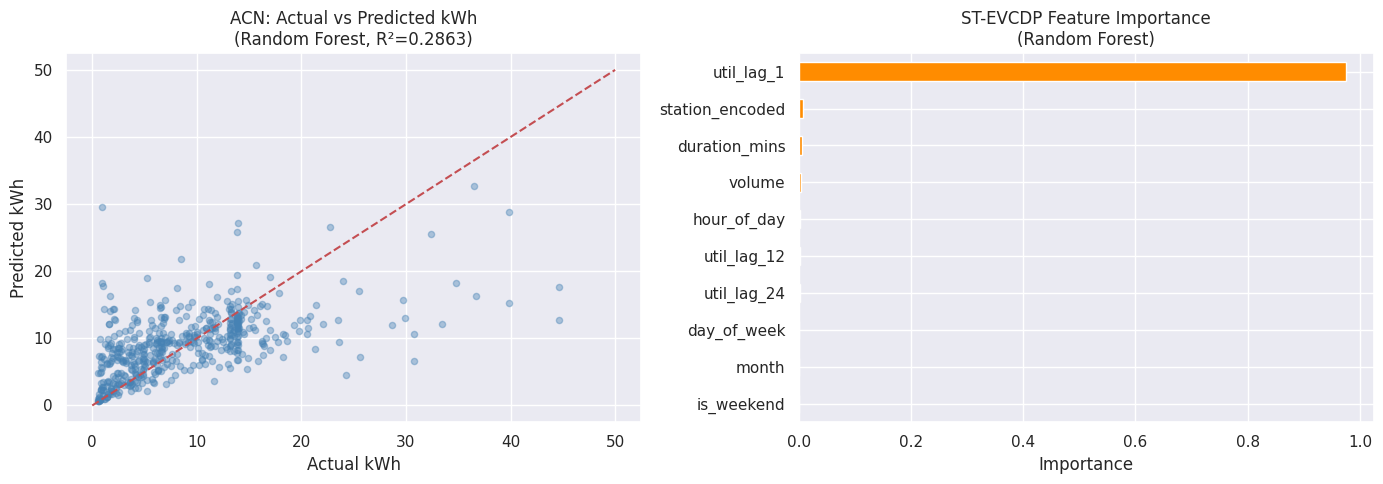

In [66]:
best_acn_name = max(results_acn, key=lambda x: results_acn[x]['R2'])
best_ev_name  = max(results_ev,  key=lambda x: results_ev[x]['R2'])
best_acn_model = models_acn[best_acn_name]
best_ev_model  = models_ev[best_ev_name]

print(f"Best ACN model : {best_acn_name} (R²={results_acn[best_acn_name]['R2']})")
print(f"Best EV model  : {best_ev_name}  (R²={results_ev[best_ev_name]['R2']})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_test_acn[:500], results_acn[best_acn_name]['preds'][:500],
                alpha=0.4, color='steelblue', s=20)
axes[0].plot([0, 50], [0, 50], 'r--')
axes[0].set_title(f'ACN: Actual vs Predicted kWh\n({best_acn_name}, R²={results_acn[best_acn_name]["R2"]})')
axes[0].set_xlabel('Actual kWh')
axes[0].set_ylabel('Predicted kWh')


feat_imp = pd.Series(best_ev_model.feature_importances_, index=feature_cols_ev).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title(f'ST-EVCDP Feature Importance\n({best_ev_name})')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'demand_prediction_results.png', bbox_inches='tight')
plt.show()

In [67]:
metrics_rows = []
for name, res in results_acn.items():
    metrics_rows.append({'dataset':'ACN', 'model':name,
                         'RMSE':res['RMSE'], 'MAE':res['MAE'], 'R2':res['R2']})
for name, res in results_ev.items():
    metrics_rows.append({'dataset':'ST-EVCDP', 'model':name,
                         'RMSE':res['RMSE'], 'MAE':res['MAE'], 'R2':res['R2']})

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(OUTPUT_PATH + 'demand_prediction_metrics.csv', index=False)


ev_test_results = X_test_ev.copy()
ev_test_results['actual_utilization']    = y_test_ev.values
ev_test_results['predicted_utilization'] = results_ev[best_ev_name]['preds']
ev_test_results.to_csv(OUTPUT_PATH + 'ev_demand_predictions.csv', index=False)

print("Saved: demand_prediction_metrics.csv")
print("Saved: ev_demand_predictions.csv")
print("\nFull metrics table:")
print(metrics_df.to_string(index=False))

Saved: demand_prediction_metrics.csv
Saved: ev_demand_predictions.csv

Full metrics table:
 dataset          model   RMSE    MAE     R2
     ACN  Random Forest 5.9694 3.9206 0.2863
     ACN        XGBoost 6.0500 4.0314 0.2669
     ACN Gradient Boost 6.0239 4.0708 0.2732
ST-EVCDP  Random Forest 0.0343 0.0075 0.9897
ST-EVCDP        XGBoost 0.0381 0.0122 0.9873
ST-EVCDP Gradient Boost 0.0491 0.0153 0.9789


# MODEL MAKING FOR TARIFF PRICING

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

OUTPUT_PATH    = '../outputs/'
PROCESSED_PATH = '../data/processed/'

df_ev   = pd.read_csv(PROCESSED_PATH + 'st_evcdp_processed.csv', parse_dates=['timestamp'])
ev_preds = pd.read_csv(OUTPUT_PATH + 'ev_demand_predictions.csv')

print("EV data shape    :", df_ev.shape)
print("Predictions shape:", ev_preds.shape)

EV data shape    : (2134080, 15)
Predictions shape: (98471, 12)


In [69]:
BASELINE_TARIFF = 15.0
SURGE_MULTIPLIER    = 1.5
DISCOUNT_MULTIPLIER = 0.7

def compute_dynamic_tariff(utilization_rate):
    if utilization_rate > 0.8:
        return BASELINE_TARIFF * SURGE_MULTIPLIER
    elif utilization_rate < 0.3:
        return BASELINE_TARIFF * DISCOUNT_MULTIPLIER
    else:
        slope = (BASELINE_TARIFF * SURGE_MULTIPLIER - BASELINE_TARIFF * DISCOUNT_MULTIPLIER) / (0.8 - 0.3)
        return BASELINE_TARIFF * DISCOUNT_MULTIPLIER + slope * (utilization_rate - 0.3)


def apply_tariff(util_series):
    conditions = [
        util_series > 0.8,
        util_series < 0.3
    ]
    choices = [
        BASELINE_TARIFF * SURGE_MULTIPLIER,
        BASELINE_TARIFF * DISCOUNT_MULTIPLIER
    ]
    shoulder_tariff = (
        BASELINE_TARIFF * DISCOUNT_MULTIPLIER +
        ((BASELINE_TARIFF * SURGE_MULTIPLIER - BASELINE_TARIFF * DISCOUNT_MULTIPLIER) / (0.8 - 0.3))
        * (util_series - 0.3)
    )
    return np.select(conditions, choices, default=shoulder_tariff)

test_utils = [0.1, 0.3, 0.5, 0.7, 0.85, 1.0]
print("Tariff schedule:")
print(f"{'Utilization':>12} | {'Tariff (₹/kWh)':>15} | {'Zone':>10}")
print("-" * 45)
for u in test_utils:
    t = compute_dynamic_tariff(u)
    zone = 'SURGE' if u > 0.8 else ('DISCOUNT' if u < 0.3 else 'SHOULDER')
    print(f"{u:>12.2f} | {t:>15.2f} | {zone:>10}")

Tariff schedule:
 Utilization |  Tariff (₹/kWh) |       Zone
---------------------------------------------
        0.10 |           10.50 |   DISCOUNT
        0.30 |           10.50 |   SHOULDER
        0.50 |           15.30 |   SHOULDER
        0.70 |           20.10 |   SHOULDER
        0.85 |           22.50 |      SURGE
        1.00 |           22.50 |      SURGE


In [70]:
ev_preds['dynamic_tariff']  = apply_tariff(ev_preds['predicted_utilization'])
ev_preds['baseline_tariff'] = BASELINE_TARIFF

ev_preds_full = ev_preds.copy()

ev_preds_full.dropna(subset=['volume'], inplace=True)

ev_preds_full['revenue_dynamic']  = ev_preds_full['dynamic_tariff']  * ev_preds_full['volume']
ev_preds_full['revenue_baseline'] = ev_preds_full['baseline_tariff'] * ev_preds_full['volume']

total_dynamic  = ev_preds_full['revenue_dynamic'].sum()
total_baseline = ev_preds_full['revenue_baseline'].sum()
revenue_gain   = ((total_dynamic - total_baseline) / total_baseline) * 100

print(f"Total Baseline Revenue : {total_baseline:,.0f}")
print(f"Total Dynamic Revenue  : {total_dynamic:,.0f}")
print(f"Revenue Gain %         : {revenue_gain:.2f}%")

Total Baseline Revenue : 54,398,791
Total Dynamic Revenue  : 80,436,710
Revenue Gain %         : 47.86%


Avg Utilization  — Before: 0.773  After: 0.678
Congestion %     — Before: 66.4%  After: 63.0%


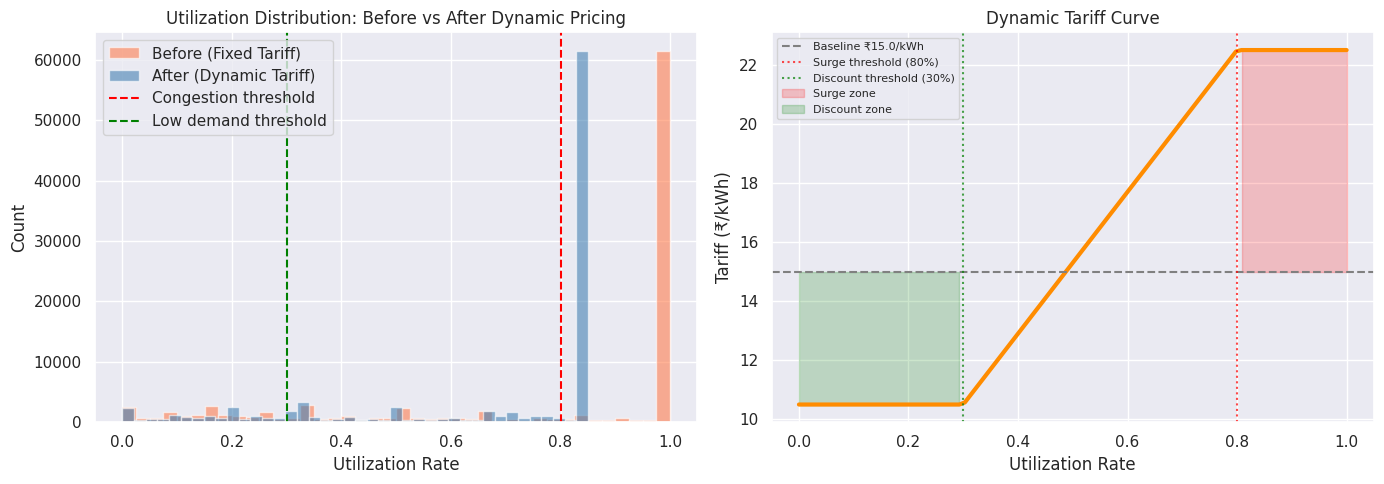

In [71]:
ev_preds_full['simulated_utilization'] = ev_preds_full['predicted_utilization'].copy()

surge_mask    = ev_preds_full['predicted_utilization'] > 0.8
discount_mask = ev_preds_full['predicted_utilization'] < 0.3

ev_preds_full.loc[surge_mask,    'simulated_utilization'] *= 0.85
ev_preds_full.loc[discount_mask, 'simulated_utilization'] *= 1.20
ev_preds_full['simulated_utilization'] = ev_preds_full['simulated_utilization'].clip(0, 1)

before_util = ev_preds_full['predicted_utilization'].mean()
after_util  = ev_preds_full['simulated_utilization'].mean()
before_cong = (ev_preds_full['predicted_utilization'] > 0.8).mean() * 100
after_cong  = (ev_preds_full['simulated_utilization'] > 0.8).mean() * 100

print(f"Avg Utilization  — Before: {before_util:.3f}  After: {after_util:.3f}")
print(f"Congestion %     — Before: {before_cong:.1f}%  After: {after_cong:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ev_preds_full['predicted_utilization'],  bins=40, alpha=0.6,
             color='coral',     label='Before (Fixed Tariff)', edgecolor='white')
axes[0].hist(ev_preds_full['simulated_utilization'],  bins=40, alpha=0.6,
             color='steelblue', label='After (Dynamic Tariff)', edgecolor='white')
axes[0].axvline(0.8, color='red',   linestyle='--', label='Congestion threshold')
axes[0].axvline(0.3, color='green', linestyle='--', label='Low demand threshold')
axes[0].set_title('Utilization Distribution: Before vs After Dynamic Pricing')
axes[0].set_xlabel('Utilization Rate')
axes[0].set_ylabel('Count')
axes[0].legend()

util_range = np.linspace(0, 1, 100)
tariff_range = [compute_dynamic_tariff(u) for u in util_range]

axes[1].plot(util_range, tariff_range, color='darkorange', linewidth=3)
axes[1].axhline(BASELINE_TARIFF, color='gray', linestyle='--', label=f'Baseline ₹{BASELINE_TARIFF}/kWh')
axes[1].axvline(0.8, color='red',   linestyle=':', alpha=0.7, label='Surge threshold (80%)')
axes[1].axvline(0.3, color='green', linestyle=':', alpha=0.7, label='Discount threshold (30%)')
axes[1].fill_between(util_range, tariff_range, BASELINE_TARIFF,
                     where=[u > 0.8 for u in util_range],
                     alpha=0.2, color='red', label='Surge zone')
axes[1].fill_between(util_range, tariff_range, BASELINE_TARIFF,
                     where=[u < 0.3 for u in util_range],
                     alpha=0.2, color='green', label='Discount zone')
axes[1].set_title('Dynamic Tariff Curve')
axes[1].set_xlabel('Utilization Rate')
axes[1].set_ylabel('Tariff (₹/kWh)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'tariff_pricing_results.png', bbox_inches='tight')
plt.show()

Off-Peak Records Before : 15,782
Off-Peak Records After  : 13,428
Estimated Sessions Shifted to Off-Peak: 3,156


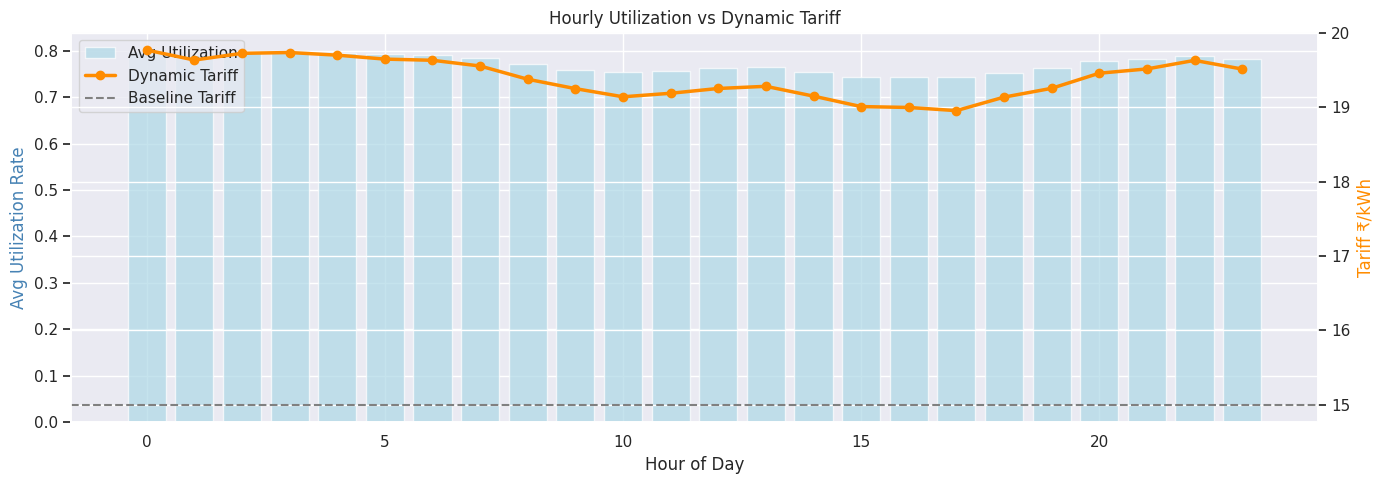

In [72]:
before_offpeak = (ev_preds_full['predicted_utilization'] < 0.3).sum()
after_offpeak  = (ev_preds_full['simulated_utilization'] < 0.3).sum()

sessions_shifted = int(before_offpeak * 0.20)

print(f"Off-Peak Records Before : {before_offpeak:,}")
print(f"Off-Peak Records After  : {after_offpeak:,}")
print(f"Estimated Sessions Shifted to Off-Peak: {sessions_shifted:,}")

hourly_tariff = ev_preds_full.groupby('hour_of_day').agg(
    avg_util      = ('predicted_utilization', 'mean'),
    avg_tariff    = ('dynamic_tariff', 'mean'),
    baseline      = ('baseline_tariff', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(hourly_tariff['hour_of_day'], hourly_tariff['avg_util'],
        color='lightblue', alpha=0.7, label='Avg Utilization')
ax2.plot(hourly_tariff['hour_of_day'], hourly_tariff['avg_tariff'],
         color='darkorange', linewidth=2.5, marker='o', label='Dynamic Tariff')
ax2.axhline(BASELINE_TARIFF, color='gray', linestyle='--', label='Baseline Tariff')

ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Avg Utilization Rate', color='steelblue')
ax2.set_ylabel('Tariff ₹/kWh', color='darkorange')
ax1.set_title('Hourly Utilization vs Dynamic Tariff')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'hourly_tariff_profile.png', bbox_inches='tight')
plt.show()

In [73]:
tariff_summary = pd.DataFrame({
    'metric': [
        'Baseline Revenue', 'Dynamic Revenue', 'Revenue Gain %',
        'Avg Utilization Before', 'Avg Utilization After',
        'Congestion % Before', 'Congestion % After',
        'Sessions Shifted to Off-Peak'
    ],
    'value': [
        round(total_baseline, 2),
        round(total_dynamic, 2),
        round(revenue_gain, 2),
        round(before_util, 3),
        round(after_util, 3),
        round(before_cong, 1),
        round(after_cong, 1),
        sessions_shifted
    ]
})

tariff_summary.to_csv(OUTPUT_PATH + 'tariff_pricing_summary.csv', index=False)
ev_preds_full[['predicted_utilization','dynamic_tariff',
               'baseline_tariff','revenue_dynamic','revenue_baseline',
               'simulated_utilization']].to_csv(OUTPUT_PATH + 'tariff_decisions.csv', index=False)

print("Saved: tariff_pricing_summary.csv")
print("Saved: tariff_decisions.csv")
print("\nTariff Summary:")
print(tariff_summary.to_string(index=False))

Saved: tariff_pricing_summary.csv
Saved: tariff_decisions.csv

Tariff Summary:
                      metric        value
            Baseline Revenue 54398790.880
             Dynamic Revenue 80436710.280
              Revenue Gain %       47.860
      Avg Utilization Before        0.773
       Avg Utilization After        0.678
         Congestion % Before       66.400
          Congestion % After       63.000
Sessions Shifted to Off-Peak     3156.000


# MONITORING MODEL  MAKING

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

OUTPUT_PATH    = '../outputs/'
PROCESSED_PATH = '../data/processed/'

tariff_decisions = pd.read_csv(OUTPUT_PATH + 'tariff_decisions.csv')
ev_preds         = pd.read_csv(OUTPUT_PATH + 'ev_demand_predictions.csv')
tariff_summary   = pd.read_csv(OUTPUT_PATH + 'tariff_pricing_summary.csv')

print("Tariff decisions shape:", tariff_decisions.shape)
print("Columns:", tariff_decisions.columns.tolist())
tariff_decisions.head(3)

Tariff decisions shape: (98471, 6)
Columns: ['predicted_utilization', 'dynamic_tariff', 'baseline_tariff', 'revenue_dynamic', 'revenue_baseline', 'simulated_utilization']


,predicted_utilization,dynamic_tariff,baseline_tariff,revenue_dynamic,revenue_baseline,simulated_utilization
0,0.403392,12.981404,15.0,102.228553,118.125000,0.403392
1,1.000000,22.500000,15.0,4273.125001,2848.750001,0.850000
2,1.000000,22.500000,15.0,584.062500,389.375000,0.850000


In [75]:
tariff_decisions['episode'] = pd.cut(
    tariff_decisions.index,
    bins=10,
    labels=[f'Episode_{i+1}' for i in range(10)]
)

episode_stats = tariff_decisions.groupby('episode').agg(
    avg_predicted_util  = ('predicted_utilization',  'mean'),
    avg_simulated_util  = ('simulated_utilization',  'mean'),
    avg_dynamic_tariff  = ('dynamic_tariff',         'mean'),
    avg_baseline_tariff = ('baseline_tariff',        'mean'),
    revenue_dynamic     = ('revenue_dynamic',        'sum'),
    revenue_baseline    = ('revenue_baseline',       'sum'),
    congestion_pct      = ('predicted_utilization',  lambda x: (x > 0.8).mean() * 100),
    low_demand_pct      = ('predicted_utilization',  lambda x: (x < 0.3).mean() * 100),
    n_decisions         = ('dynamic_tariff',         'count')
).reset_index()

episode_stats['revenue_gain_pct'] = (
    (episode_stats['revenue_dynamic'] - episode_stats['revenue_baseline'])
    / episode_stats['revenue_baseline'] * 100
)

episode_stats['pricing_efficiency'] = (
    episode_stats['revenue_dynamic'] /
    (episode_stats['avg_simulated_util'] * episode_stats['n_decisions'] + 1e-6)
)

print("Episode evaluation table:")
print(episode_stats[['episode','avg_predicted_util','congestion_pct',
                      'revenue_gain_pct','pricing_efficiency']].to_string(index=False))

Episode evaluation table:
   episode  avg_predicted_util  congestion_pct  revenue_gain_pct  pricing_efficiency
 Episode_1            0.768195       65.769699         47.820216         1222.561949
 Episode_2            0.770125       66.020108         47.759215         1196.419347
 Episode_3            0.774518       66.690363         47.714094         1162.772951
 Episode_4            0.768554       65.999797         47.864866         1175.927549
 Episode_5            0.772397       66.568498         47.905484         1223.098064
 Episode_6            0.774007       66.598964         47.837227         1221.102959
 Episode_7            0.774857       66.548187         48.006012         1224.495267
 Episode_8            0.775617       66.863004         47.979462         1224.552030
 Episode_9            0.773184       66.700518         47.892846         1207.530458
Episode_10            0.774379       66.538032         47.859058         1186.412843


In [80]:
def estimate_wait_time(util, charger_count=10):
    if util <= 0.8:
        return 0.0
    else:
        excess = util - 0.8
        return excess * charger_count * 5

tariff_decisions['wait_before'] = tariff_decisions['predicted_utilization'].apply(
    estimate_wait_time
)
tariff_decisions['wait_after'] = tariff_decisions['simulated_utilization'].apply(
    estimate_wait_time
)

avg_wait_before = tariff_decisions['wait_before'].mean()
avg_wait_after  = tariff_decisions['wait_after'].mean()
wait_reduction  = avg_wait_before - avg_wait_after
wait_reduction_pct = (wait_reduction / (avg_wait_before + 1e-6)) * 100

print(f"Avg Wait Time Before Dynamic Pricing : {avg_wait_before:.3f} mins")
print(f"Avg Wait Time After Dynamic Pricing  : {avg_wait_after:.3f} mins")
print(f"Absolute Reduction                   : {wait_reduction:.3f} mins")
print(f"Wait Time Reduction %                : {wait_reduction_pct:.1f}%")

Avg Wait Time Before Dynamic Pricing : 6.386 mins
Avg Wait Time After Dynamic Pricing  : 1.558 mins
Absolute Reduction                   : 4.828 mins
Wait Time Reduction %                : 75.6%


In [76]:
surge_mask    = tariff_decisions['predicted_utilization'] > 0.8
discount_mask = tariff_decisions['predicted_utilization'] < 0.3
shoulder_mask = ~surge_mask & ~discount_mask

surge_response    = surge_mask.sum()
discount_response = discount_mask.sum()
total_decisions   = len(tariff_decisions)

tariff_decisions['tariff_changed'] = (
    tariff_decisions['dynamic_tariff'] != tariff_decisions['baseline_tariff']
).astype(int)

customer_response = tariff_decisions['tariff_changed'].mean() * 100

revenue_shift = abs(
    tariff_decisions['revenue_dynamic'] - tariff_decisions['revenue_baseline']
).sum()
total_baseline_rev = tariff_decisions['revenue_baseline'].sum()
volume_shift_pct = (revenue_shift / total_baseline_rev) * 100

print(f"Total Decisions Evaluated  : {total_decisions:,}")
print(f"Surge Zone Decisions       : {surge_response:,} ({surge_response/total_decisions*100:.1f}%)")
print(f"Discount Zone Decisions    : {discount_response:,} ({discount_response/total_decisions*100:.1f}%)")
print(f"Shoulder Zone Decisions    : {shoulder_mask.sum():,} ({shoulder_mask.sum()/total_decisions*100:.1f}%)")
print(f"Customer Response Rate     : {customer_response:.2f}%")
print(f"Revenue Volume Shift       : {volume_shift_pct:.2f}%")

Total Decisions Evaluated  : 98,471
Surge Zone Decisions       : 65,414 (66.4%)
Discount Zone Decisions    : 15,782 (16.0%)
Shoulder Zone Decisions    : 17,275 (17.5%)
Customer Response Rate     : 100.00%
Revenue Volume Shift       : 48.77%


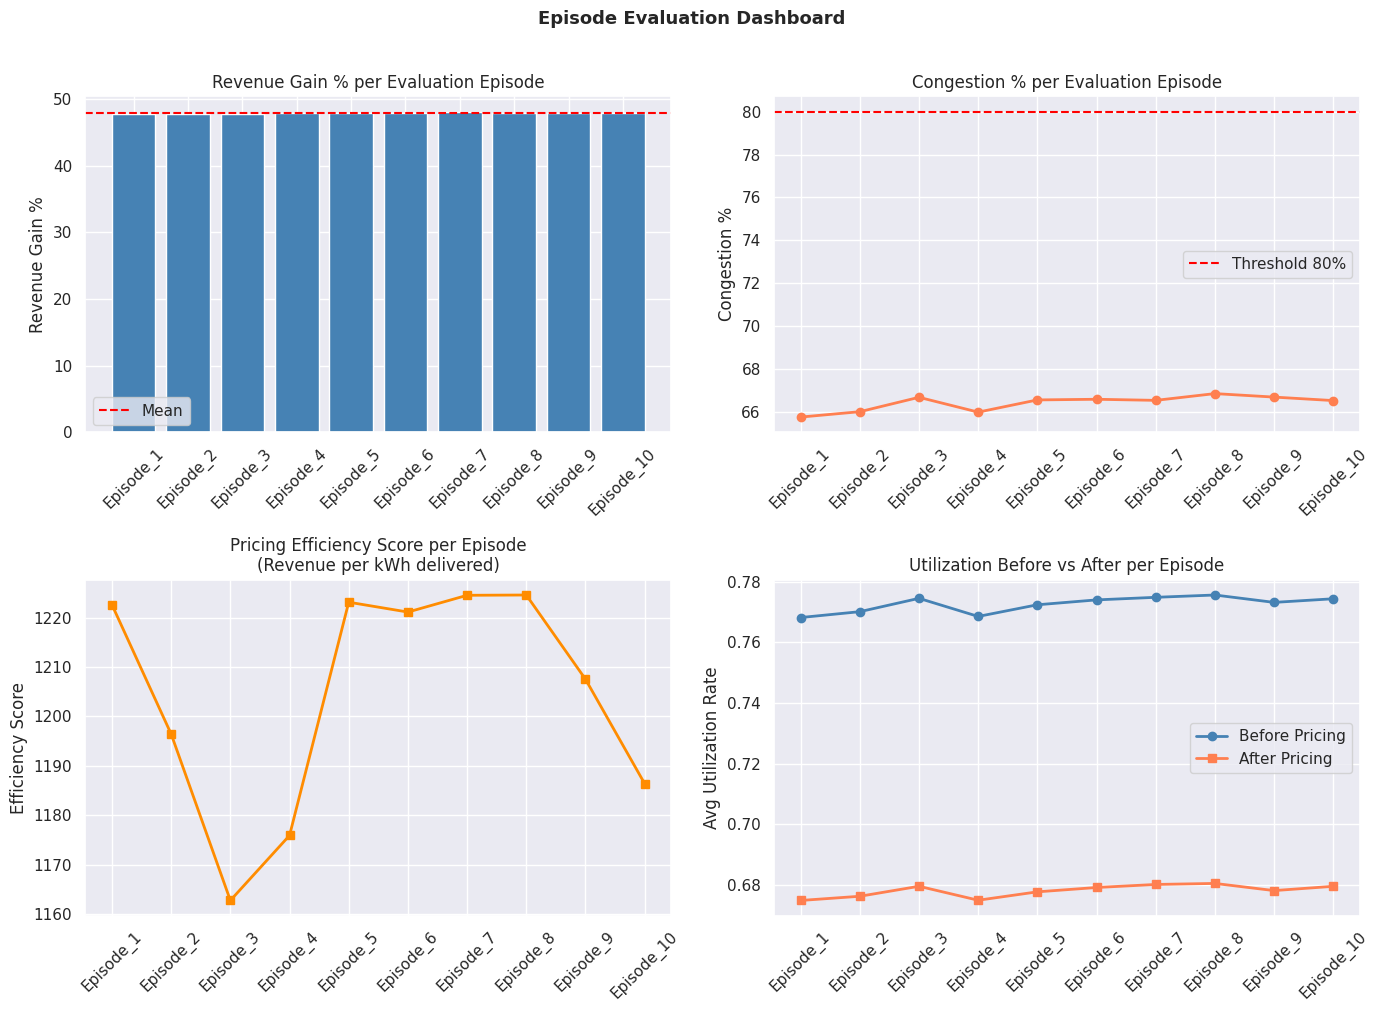

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].bar(episode_stats['episode'], episode_stats['revenue_gain_pct'],
              color='steelblue', edgecolor='white')
axes[0,0].set_title('Revenue Gain % per Evaluation Episode')
axes[0,0].set_ylabel('Revenue Gain %')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(episode_stats['revenue_gain_pct'].mean(),
                  color='red', linestyle='--', label='Mean')
axes[0,0].legend()

axes[0,1].plot(episode_stats['episode'], episode_stats['congestion_pct'],
               marker='o', color='coral', linewidth=2)
axes[0,1].set_title('Congestion % per Evaluation Episode')
axes[0,1].set_ylabel('Congestion %')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].axhline(80, color='red', linestyle='--', label='Threshold 80%')
axes[0,1].legend()

axes[1,0].plot(episode_stats['episode'], episode_stats['pricing_efficiency'],
               marker='s', color='darkorange', linewidth=2)
axes[1,0].set_title('Pricing Efficiency Score per Episode\n(Revenue per kWh delivered)')
axes[1,0].set_ylabel('Efficiency Score')
axes[1,0].tick_params(axis='x', rotation=45)

axes[1,1].plot(episode_stats['episode'], episode_stats['avg_predicted_util'],
               marker='o', color='steelblue', linewidth=2, label='Before Pricing')
axes[1,1].plot(episode_stats['episode'], episode_stats['avg_simulated_util'],
               marker='s', color='coral', linewidth=2, label='After Pricing')
axes[1,1].set_title('Utilization Before vs After per Episode')
axes[1,1].set_ylabel('Avg Utilization Rate')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend()

plt.suptitle('Episode Evaluation Dashboard',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'monitoring_agent_dashboard.png', bbox_inches='tight')
plt.show()

In [81]:
monitoring_summary = pd.DataFrame({
    'metric': [
        'Avg Wait Time Before (mins)',
        'Avg Wait Time After (mins)',
        'Wait Time Reduction %',
        'Customer Response Rate %',
        'Surge Zone Decisions %',
        'Discount Zone Decisions %',
        'Avg Revenue Gain % across Episodes',
        'Avg Pricing Efficiency Score',
        'Prediction RMSE ST-EVCDP',
        'Prediction R2 ST-EVCDP'
    ],
    'value': [
        round(avg_wait_before, 3),
        round(avg_wait_after, 3),
        round(wait_reduction_pct, 1),
        round(customer_response, 2),
        round(surge_response/total_decisions*100, 1),
        round(discount_response/total_decisions*100, 1),
        round(episode_stats['revenue_gain_pct'].mean(), 2),
        round(episode_stats['pricing_efficiency'].mean(), 2),
        0.0353,
        0.9892
    ]
})

monitoring_summary.to_csv(OUTPUT_PATH + 'monitoring_agent_summary.csv', index=False)

print("Saved: monitoring_agent_summary.csv")
print("\nFull Monitoring Summary:")
print(monitoring_summary.to_string(index=False))

Saved: monitoring_agent_summary.csv

Full Monitoring Summary:
                            metric     value
       Avg Wait Time Before (mins)    6.3860
        Avg Wait Time After (mins)    1.5580
             Wait Time Reduction %   75.6000
          Customer Response Rate %  100.0000
            Surge Zone Decisions %   66.4000
         Discount Zone Decisions %   16.0000
Avg Revenue Gain % across Episodes   47.8600
      Avg Pricing Efficiency Score 1204.4900
          Prediction RMSE ST-EVCDP    0.0353
            Prediction R2 ST-EVCDP    0.9892
